
========== 真实 RLC 参数 ==========
假设拓扑：串联 RLC，输出取 R 两端，带通
R = 1000.000 Ω
L = 4.700000e-03 H
C = 1.000000e-08 F
f0 = 23215.134 Hz
Q  = 0.685565

真实传递函数：
H_true(s) = (2.127660e+05s) / (s^2 + 2.127660e+05s + 2.127660e+10)

正在打开串口 COM11，波特率 115200 ...
串口已打开，等待 STM32 发送扫频数据...
数据格式：mag,phase_deg,freq_hz
收到 SWEEP_DONE 后开始绘图和拟合。

mag,phase_deg,freq_hz
0.071172,84.09,1000
0.085523,81.95,1200
0.102052,80.21,1400
0.120563,79.02,1600
0.136529,77.95,1800
0.149873,76.77,2000
0.168816,75.23,2200
0.184499,73.66,2400
0.198829,72.70,2599
0.215684,71.60,2800
0.232873,70.45,2999
0.246585,69.32,3201
0.263748,68.22,3399
0.280462,67.00,3599
0.294924,65.97,3798
0.310302,64.88,3997
0.328216,63.79,4198
0.343112,62.62,4400
0.357881,61.53,4599
0.375420,60.50,4799
0.390811,59.26,5000
0.398924,52.20,5198
0.414667,51.07,5397
0.432004,50.24,5601
0.446819,49.33,5802
0.461978,48.19,5998
0.479465,47.03,6201
0.494265,46.12,6403
0.508832,44.58,6603
0.525534,43.44,6799
0.539447,42.51,6997
0.553887,41.29,7199
0.569852,40.16

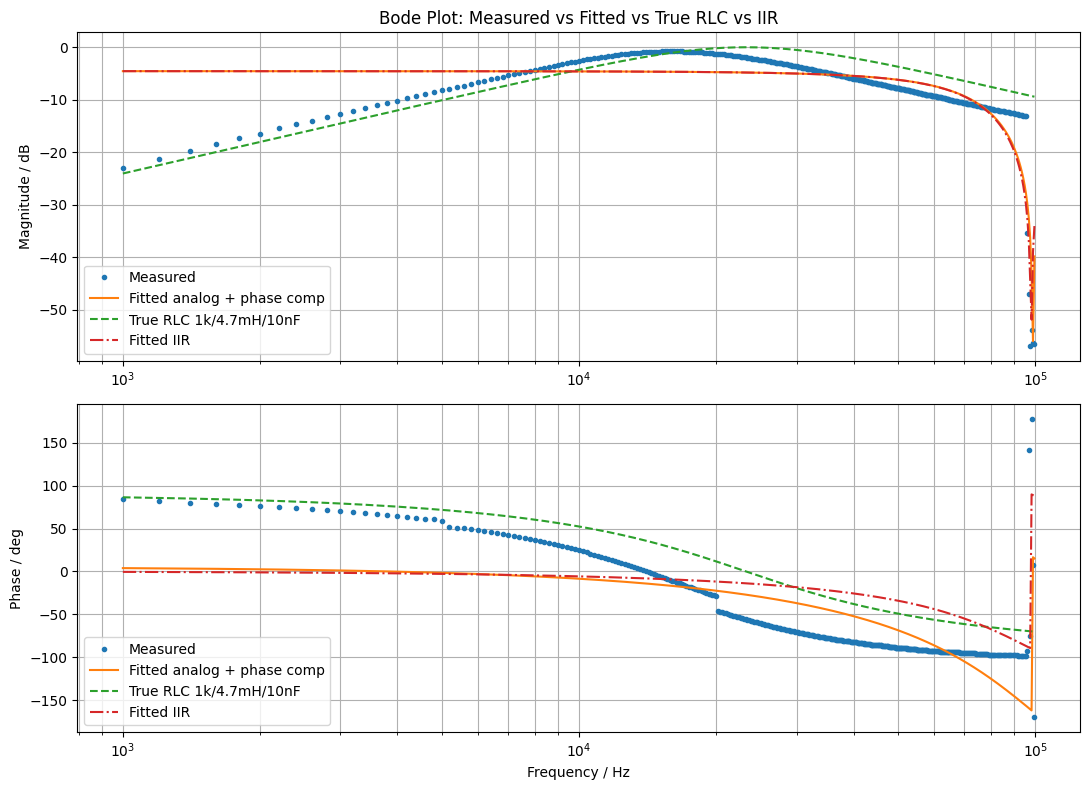

In [3]:
import re
import serial
import serial.tools.list_ports
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import least_squares
from scipy import signal


# =========================
# 串口参数
# =========================
PORT = "COM11"
BAUDRATE = 115200
TIMEOUT = 1

# 如果之前 COM11 报错，可以改成 True，运行时手动选择串口
AUTO_SELECT_PORT = False


# =========================
# 真实 RLC 参数
# 串联 RLC，输出取 R 两端，表现为带通
# =========================
R_TRUE = 1000.0       # 1 kΩ
L_TRUE = 4.7e-3      # 4.7 mH
C_TRUE = 10e-9       # 10 nF
TRUE_GAIN = 1.0


# =========================
# IIR 设计采样率
# 这个要改成你 STM32 实时滤波阶段的采样率
# =========================
IIR_FS_HZ = 2_000_000.0


# =========================
# 串口选择
# =========================
def select_serial_port():
    ports = list(serial.tools.list_ports.comports())

    if not ports:
        raise RuntimeError("没有检测到任何串口设备，请检查 USB 连接、驱动和开发板供电。")

    print("检测到以下串口：")
    for i, p in enumerate(ports):
        print(f"{i}: {p.device} - {p.description}")

    index = int(input("请选择串口编号："))

    if index < 0 or index >= len(ports):
        raise ValueError("串口编号无效。")

    return ports[index].device


# =========================
# 串口数据解析
# =========================
def parse_line(line):
    """
    支持两种格式：

    1. 无时间戳：
       0.010612,179.40,1000

    2. 有串口软件时间戳：
       [23:24:18.249] 0.010612,179.40,1000
    """

    line = line.strip()

    # 去掉串口软件时间戳
    line = re.sub(r"^\[\d{2}:\d{2}:\d{2}\.\d{3}\]\s*", "", line)

    if not line:
        return None

    if line.startswith("mag"):
        return None

    if line.startswith("SWEEP_DONE"):
        return "DONE"

    parts = line.split(",")

    if len(parts) != 3:
        return None

    try:
        mag = float(parts[0])
        phase_deg = float(parts[1])
        freq_hz = float(parts[2])
    except ValueError:
        return None

    return mag, phase_deg, freq_hz


def receive_sweep_data():
    freq_list = []
    mag_list = []
    phase_list = []

    print(f"正在打开串口 {PORT}，波特率 {BAUDRATE} ...")

    with serial.Serial(PORT, BAUDRATE, timeout=TIMEOUT) as ser:
        print("串口已打开，等待 STM32 发送扫频数据...")
        print("数据格式：mag,phase_deg,freq_hz")
        print("收到 SWEEP_DONE 后开始绘图和拟合。\n")

        while True:
            raw = ser.readline()

            if not raw:
                continue

            line = raw.decode("utf-8", errors="ignore").strip()
            print(line)

            result = parse_line(line)

            if result is None:
                continue

            if result == "DONE":
                print("\n收到 SWEEP_DONE，数据接收完成。")
                break

            mag, phase_deg, freq_hz = result

            mag_list.append(mag)
            phase_list.append(phase_deg)
            freq_list.append(freq_hz)

    freq = np.array(freq_list, dtype=float)
    mag = np.array(mag_list, dtype=float)
    phase = np.array(phase_list, dtype=float)

    index = np.argsort(freq)

    return freq[index], mag[index], phase[index]


# =========================
# 二阶 RLC 标准模型
# =========================
def rlc_transfer(kind, freq_hz, K, f0, Q):
    """
    kind:
        LP : 低通
        HP : 高通
        BP : 带通
        BS : 带阻
    """

    s = 1j * 2 * np.pi * freq_hz
    w0 = 2 * np.pi * f0

    den = s**2 + (w0 / Q) * s + w0**2

    if kind == "LP":
        num = w0**2

    elif kind == "HP":
        num = s**2

    elif kind == "BP":
        num = (w0 / Q) * s

    elif kind == "BS":
        num = s**2 + w0**2

    else:
        raise ValueError("未知滤波器类型")

    return K * num / den


# =========================
# 真实 RLC 带通模型
# 串联 RLC，输出取 R 两端
# =========================
def true_series_rlc_bandpass(freq_hz):
    s = 1j * 2 * np.pi * freq_hz

    den = s**2 + (R_TRUE / L_TRUE) * s + 1.0 / (L_TRUE * C_TRUE)
    num = (R_TRUE / L_TRUE) * s

    return TRUE_GAIN * num / den


def print_true_rlc_info():
    w0 = 1.0 / np.sqrt(L_TRUE * C_TRUE)
    f0 = w0 / (2 * np.pi)
    q = w0 * L_TRUE / R_TRUE

    a1 = R_TRUE / L_TRUE
    a0 = 1.0 / (L_TRUE * C_TRUE)
    b1 = R_TRUE / L_TRUE

    print("\n========== 真实 RLC 参数 ==========")
    print("假设拓扑：串联 RLC，输出取 R 两端，带通")
    print(f"R = {R_TRUE:.3f} Ω")
    print(f"L = {L_TRUE:.6e} H")
    print(f"C = {C_TRUE:.6e} F")
    print(f"f0 = {f0:.3f} Hz")
    print(f"Q  = {q:.6f}")
    print("\n真实传递函数：")
    print(f"H_true(s) = ({b1:.6e}s) / (s^2 + {a1:.6e}s + {a0:.6e})")
    print("==================================\n")


# =========================
# 幅值拟合，判断系统类型
# =========================
def fit_mag_only(freq, mag):
    kinds = ["LP", "HP", "BP", "BS"]

    best = None

    for kind in kinds:
        def residual(p):
            logK, logf0, logQ = p

            K = np.exp(logK)
            f0 = np.exp(logf0)
            Q = np.exp(logQ)

            H = rlc_transfer(kind, freq, K, f0, Q)

            err = np.log(np.maximum(np.abs(H), 1e-12)) - np.log(np.maximum(mag, 1e-12))

            return err

        f_min = max(np.min(freq), 10.0)
        f_max = max(np.max(freq), f_min * 10)

        f0_guesses = np.geomspace(f_min, f_max, 10)
        q_guesses = [0.2, 0.3, 0.5, 0.7, 1.0, 1.5, 2.0, 5.0]

        for f0_guess in f0_guesses:
            for q_guess in q_guesses:
                p0 = [
                    np.log(max(np.max(mag), 1e-6)),
                    np.log(f0_guess),
                    np.log(q_guess),
                ]

                bounds_low = [
                    np.log(1e-6),
                    np.log(10.0),
                    np.log(0.05),
                ]

                bounds_high = [
                    np.log(1000.0),
                    np.log(10e6),
                    np.log(200.0),
                ]

                result = least_squares(
                    residual,
                    p0,
                    bounds=(bounds_low, bounds_high),
                    max_nfev=3000,
                )

                rms = np.sqrt(np.mean(result.fun**2))

                if best is None or rms < best["rms"]:
                    logK, logf0, logQ = result.x

                    best = {
                        "kind": kind,
                        "K": float(np.exp(logK)),
                        "f0": float(np.exp(logf0)),
                        "Q": float(np.exp(logQ)),
                        "rms": float(rms),
                    }

    return best


# =========================
# 加入相位偏置和等效延迟的复数拟合
# =========================
def fit_complex_with_phase(freq, mag, phase_deg, initial_fit):
    kind = initial_fit["kind"]

    phase_rad = np.deg2rad(phase_deg)

    def residual(p):
        logK, logf0, logQ, phase_offset_rad, delay_s = p

        K = np.exp(logK)
        f0 = np.exp(logf0)
        Q = np.exp(logQ)

        H = rlc_transfer(kind, freq, K, f0, Q)

        # 这个补偿用于贴合你的测量相位；
        # 后续真正生成 IIR 时，不把这个相位偏置放进 biquad。
        H = H * np.exp(1j * (phase_offset_rad - 2 * np.pi * freq * delay_s))

        mag_pred = np.abs(H)
        phase_pred = np.angle(H)

        mag_err = np.log(np.maximum(mag_pred, 1e-12)) - np.log(np.maximum(mag, 1e-12))

        phase_err = np.angle(np.exp(1j * (phase_pred - phase_rad)))

        phase_weight = 0.25

        return np.concatenate([
            mag_err,
            phase_weight * phase_err,
        ])

    best = None

    f0_base = initial_fit["f0"]
    q_base = initial_fit["Q"]
    k_base = initial_fit["K"]

    f0_guesses = [
        f0_base * 0.7,
        f0_base,
        f0_base * 1.3,
    ]

    q_guesses = [
        max(q_base * 0.5, 0.05),
        q_base,
        q_base * 2.0,
    ]

    delay_guesses = [
        0.0,
        0.1e-6,
        -0.1e-6,
        0.5e-6,
        -0.5e-6,
        1.0e-6,
        -1.0e-6,
    ]

    phase_guesses = [
        0.0,
        np.deg2rad(30),
        np.deg2rad(-30),
        np.deg2rad(90),
        np.deg2rad(-90),
    ]

    for f0_guess in f0_guesses:
        for q_guess in q_guesses:
            for delay_guess in delay_guesses:
                for phase_guess in phase_guesses:
                    p0 = [
                        np.log(max(k_base, 1e-6)),
                        np.log(max(f0_guess, 10.0)),
                        np.log(max(q_guess, 0.05)),
                        phase_guess,
                        delay_guess,
                    ]

                    bounds_low = [
                        np.log(1e-6),
                        np.log(10.0),
                        np.log(0.05),
                        -20 * np.pi,
                        -100e-6,
                    ]

                    bounds_high = [
                        np.log(1000.0),
                        np.log(10e6),
                        np.log(200.0),
                        20 * np.pi,
                        100e-6,
                    ]

                    result = least_squares(
                        residual,
                        p0,
                        bounds=(bounds_low, bounds_high),
                        max_nfev=5000,
                    )

                    rms = np.sqrt(np.mean(result.fun**2))

                    if best is None or rms < best["rms"]:
                        logK, logf0, logQ, phase_offset_rad, delay_s = result.x

                        best = {
                            "kind": kind,
                            "K": float(np.exp(logK)),
                            "f0": float(np.exp(logf0)),
                            "Q": float(np.exp(logQ)),
                            "phase_offset_rad": float(phase_offset_rad),
                            "phase_offset_deg": float(np.rad2deg(phase_offset_rad)),
                            "delay_s": float(delay_s),
                            "rms": float(rms),
                        }

    return best


# =========================
# 模拟域系数
# =========================
def analog_coeffs_from_fit(fit):
    kind = fit["kind"]
    K = fit["K"]
    f0 = fit["f0"]
    Q = fit["Q"]

    w0 = 2 * np.pi * f0

    a_s = np.array([
        1.0,
        w0 / Q,
        w0**2,
    ], dtype=float)

    if kind == "LP":
        b_s = np.array([
            0.0,
            0.0,
            K * w0**2,
        ], dtype=float)

    elif kind == "HP":
        b_s = np.array([
            K,
            0.0,
            0.0,
        ], dtype=float)

    elif kind == "BP":
        b_s = np.array([
            0.0,
            K * w0 / Q,
            0.0,
        ], dtype=float)

    elif kind == "BS":
        b_s = np.array([
            K,
            0.0,
            K * w0**2,
        ], dtype=float)

    else:
        raise ValueError("未知滤波器类型")

    return b_s, a_s


def design_iir_from_fit(fit, fs_hz):
    """
    将拟合得到的模拟域二阶系统通过双线性变换转换为数字 IIR。
    返回 b_z, a_z。
    """

    b_s, a_s = analog_coeffs_from_fit(fit)

    b_z, a_z = signal.bilinear(b_s, a_s, fs=fs_hz)

    # 归一化，保证 a0 = 1
    b_z = b_z / a_z[0]
    a_z = a_z / a_z[0]

    return b_z, a_z


def iir_response_at_freq(freq_hz, b_z, a_z, fs_hz):
    """
    计算 IIR 在指定频率点上的频响。
    freq_hz 必须小于 fs/2。
    """

    w = 2 * np.pi * freq_hz / fs_hz
    _, h = signal.freqz(b_z, a_z, worN=w)

    return h


def print_iir_coeffs(b_z, a_z):
    print("\n========== 拟合 IIR 系数 ==========")
    print(f"Fs = {IIR_FS_HZ:.3f} Hz")
    print("差分方程：")
    print("y[n] = b0*x[n] + b1*x[n-1] + b2*x[n-2] - a1*y[n-1] - a2*y[n-2]")
    print("\nfloat 系数：")
    print(f"b0 = {b_z[0]: .12e}")
    print(f"b1 = {b_z[1]: .12e}")
    print(f"b2 = {b_z[2]: .12e}")
    print(f"a1 = {a_z[1]: .12e}")
    print(f"a2 = {a_z[2]: .12e}")

    print("\nC 数组形式：")
    print(f"float b[3] = {{{b_z[0]:.12e}f, {b_z[1]:.12e}f, {b_z[2]:.12e}f}};")
    print(f"float a[3] = {{{a_z[0]:.12e}f, {a_z[1]:.12e}f, {a_z[2]:.12e}f}};")
    print("==================================\n")


# =========================
# 打印拟合传递函数
# =========================
def print_system_equation(fit):
    kind = fit["kind"]
    K = fit["K"]
    f0 = fit["f0"]
    Q = fit["Q"]

    w0 = 2 * np.pi * f0
    a1 = w0 / Q
    a0 = w0**2

    print("\n========== RLC 拟合结果 ==========")

    if kind == "LP":
        print("系统类型：二阶低通 RLC")
        b0 = K * w0**2
        print(f"H_fit(s) = {b0:.6e} / (s^2 + {a1:.6e}s + {a0:.6e})")

    elif kind == "HP":
        print("系统类型：二阶高通 RLC")
        b2 = K
        print(f"H_fit(s) = ({b2:.6e}s^2) / (s^2 + {a1:.6e}s + {a0:.6e})")

    elif kind == "BP":
        print("系统类型：二阶带通 RLC")
        b1 = K * w0 / Q
        print(f"H_fit(s) = ({b1:.6e}s) / (s^2 + {a1:.6e}s + {a0:.6e})")

    elif kind == "BS":
        print("系统类型：二阶带阻 RLC")
        b2 = K
        b0 = K * w0**2
        print(f"H_fit(s) = ({b2:.6e}s^2 + {b0:.6e}) / (s^2 + {a1:.6e}s + {a0:.6e})")

    print("\n参数：")
    print(f"K  = {K:.8f}")
    print(f"f0 = {f0:.3f} Hz")
    print(f"Q  = {Q:.8f}")
    print(f"w0 = {w0:.6e} rad/s")
    print(f"a1 = w0/Q = {a1:.6e}")
    print(f"a0 = w0^2 = {a0:.6e}")

    if "phase_offset_deg" in fit:
        print("\n相位补偿参数，仅用于画图拟合测量相位，不进入 biquad：")
        print(f"phase_offset = {fit['phase_offset_deg']:.3f} deg")
        print(f"delay         = {fit['delay_s'] * 1e9:.3f} ns")

    print("==================================\n")


# =========================
# 绘制伯德图：实测 / 拟合 / 真实 RLC / 拟合 IIR
# =========================
def plot_bode_compare(freq, mag, phase_deg, fit, b_z, a_z):
    mag_db = 20 * np.log10(np.maximum(mag, 1e-12))

    # 拟合模拟域模型，不加相位补偿，用于生成 IIR
    H_fit_pure = rlc_transfer(fit["kind"], freq, fit["K"], fit["f0"], fit["Q"])

    # 拟合模拟域模型，加相位补偿，用于贴合测量相位
    H_fit_phase = H_fit_pure.copy()
    if "phase_offset_rad" in fit:
        H_fit_phase = H_fit_phase * np.exp(
            1j * (
                fit["phase_offset_rad"]
                - 2 * np.pi * freq * fit["delay_s"]
            )
        )

    # 真实 RLC 模型
    H_true = true_series_rlc_bandpass(freq)

    # 拟合出来的 IIR 系数频响
    valid_iir = freq < (IIR_FS_HZ / 2.0)

    H_iir = np.full_like(freq, np.nan, dtype=complex)
    H_iir[valid_iir] = iir_response_at_freq(freq[valid_iir], b_z, a_z, IIR_FS_HZ)

    plt.figure(figsize=(11, 8))

    # 幅频
    plt.subplot(2, 1, 1)
    plt.semilogx(freq, mag_db, ".", label="Measured")
    plt.semilogx(freq, 20 * np.log10(np.maximum(np.abs(H_fit_phase), 1e-12)), "-", label="Fitted analog + phase comp")
    plt.semilogx(freq, 20 * np.log10(np.maximum(np.abs(H_true), 1e-12)), "--", label="True RLC 1k/4.7mH/10nF")
    plt.semilogx(freq[valid_iir], 20 * np.log10(np.maximum(np.abs(H_iir[valid_iir]), 1e-12)), "-.", label="Fitted IIR")

    plt.grid(True, which="both")
    plt.ylabel("Magnitude / dB")
    plt.title("Bode Plot: Measured vs Fitted vs True RLC vs IIR")
    plt.legend()

    # 相频
    plt.subplot(2, 1, 2)
    plt.semilogx(freq, phase_deg, ".", label="Measured")
    plt.semilogx(freq, np.rad2deg(np.angle(H_fit_phase)), "-", label="Fitted analog + phase comp")
    plt.semilogx(freq, np.rad2deg(np.angle(H_true)), "--", label="True RLC 1k/4.7mH/10nF")
    plt.semilogx(freq[valid_iir], np.rad2deg(np.angle(H_iir[valid_iir])), "-.", label="Fitted IIR")

    plt.grid(True, which="both")
    plt.xlabel("Frequency / Hz")
    plt.ylabel("Phase / deg")
    plt.legend()

    plt.tight_layout()
    plt.show()


# =========================
# 主程序
# =========================
if __name__ == "__main__":
    if AUTO_SELECT_PORT:
        PORT = select_serial_port()

    print_true_rlc_info()

    freq, mag, phase_deg = receive_sweep_data()

    if len(freq) < 10:
        print("有效数据太少，无法拟合。")
        exit()

    # 去掉无效点
    valid = (
        np.isfinite(freq)
        & np.isfinite(mag)
        & np.isfinite(phase_deg)
        & (freq > 0)
        & (mag > 1e-8)
    )

    freq_fit = freq[valid]
    mag_fit = mag[valid]
    phase_fit = phase_deg[valid]

    # 第一步：幅值拟合，判断 RLC 类型
    mag_result = fit_mag_only(freq_fit, mag_fit)

    print("\n========== 幅值拟合判断 ==========")
    print(f"类型 = {mag_result['kind']}")
    print(f"K    = {mag_result['K']:.8f}")
    print(f"f0   = {mag_result['f0']:.3f} Hz")
    print(f"Q    = {mag_result['Q']:.8f}")
    print(f"RMS  = {mag_result['rms']:.8f}")
    print("==================================")

    # 第二步：加入相位偏置和延迟，做完整拟合
    final_result = fit_complex_with_phase(freq_fit, mag_fit, phase_fit, mag_result)

    print_system_equation(final_result)

    # 第三步：由拟合模拟域模型生成 IIR 系数
    b_z, a_z = design_iir_from_fit(final_result, IIR_FS_HZ)

    print_iir_coeffs(b_z, a_z)

    # 第四步：绘制对比图
    plot_bode_compare(freq_fit, mag_fit, phase_fit, final_result, b_z, a_z)


========== 相位整体平移误差分析 ==========

[1] 拟合模拟域模型，不带相位补偿
最佳常数相位平移 = -30.575 deg
平移后相位 RMS 误差 = 2.031 deg

[2] 拟合模拟域模型，带原 phase_offset / delay
还需要额外相位平移 = -0.014 deg
额外平移后相位 RMS 误差 = 1.770 deg

[3] 拟合 IIR，只允许常数相位平移
IIR 最佳常数相位平移 = -30.528 deg
IIR 平移后相位 RMS 误差 = 2.048 deg

[4] 拟合 IIR，允许常数相位 + 等效延迟
IIR 最佳常数相位平移 = -32.251 deg
IIR 最佳等效延迟 = -113.921 ns
IIR 补偿后相位 RMS 误差 = 1.773 deg



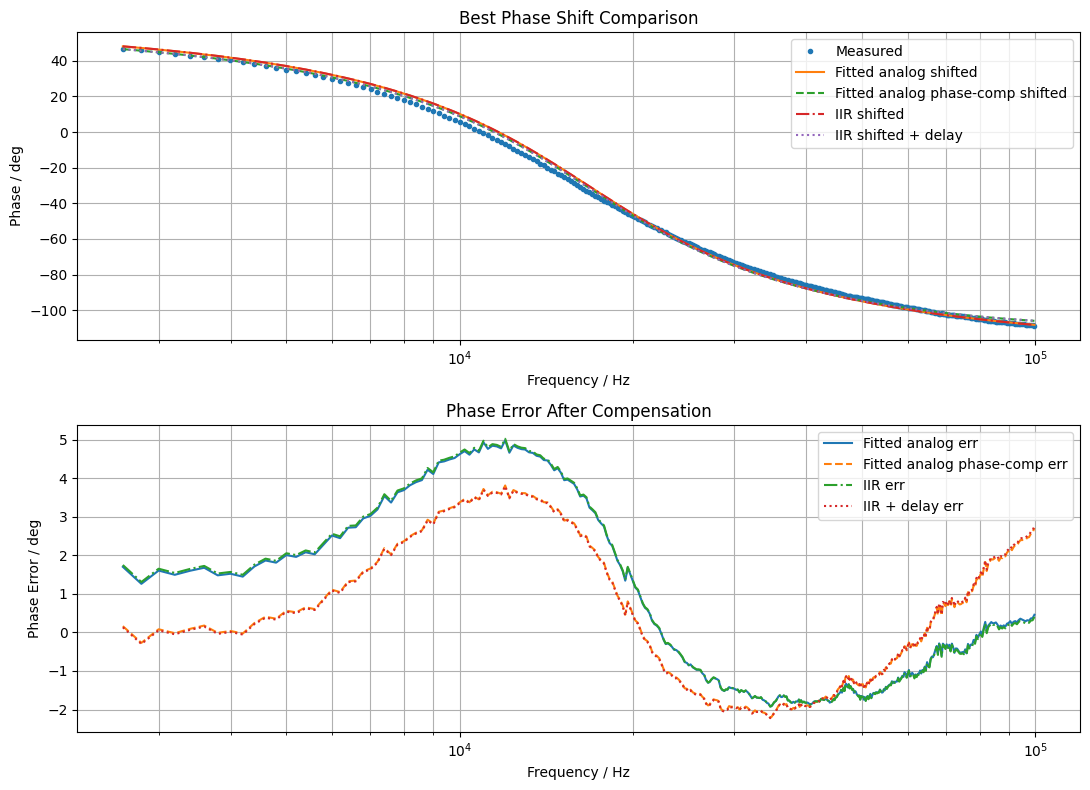

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import least_squares


# =========================
# 相位误差工具函数
# =========================
def wrap_phase_deg(x):
    """
    把相位误差限制到 -180 ~ 180 deg
    """
    return (x + 180.0) % 360.0 - 180.0


def phase_rms_deg(phase_err_deg):
    """
    计算相位 RMS 误差
    """
    return np.sqrt(np.mean(wrap_phase_deg(phase_err_deg) ** 2))


def best_constant_phase_shift(phase_meas_deg, phase_model_deg):
    """
    只允许模型曲线整体上下平移一个常数相位 offset_deg。
    寻找 phase_model + offset_deg 与 phase_meas 误差最小时的 offset。
    """

    def residual(x):
        offset_deg = x[0]
        return wrap_phase_deg((phase_model_deg + offset_deg) - phase_meas_deg)

    result = least_squares(residual, x0=[0.0])

    offset_deg = result.x[0]
    err_deg = wrap_phase_deg((phase_model_deg + offset_deg) - phase_meas_deg)
    rms = phase_rms_deg(err_deg)

    return offset_deg, rms, err_deg


def best_phase_shift_and_delay(freq_hz, phase_meas_deg, phase_model_deg):
    """
    允许两个补偿量：
    1. 常数相位 offset_deg
    2. 等效延迟 delay_s

    修正模型：
    phase_corrected = phase_model + offset_deg - 360 * f * delay_s
    """

    def residual(x):
        offset_deg = x[0]
        delay_s = x[1]

        phase_corr = phase_model_deg + offset_deg - 360.0 * freq_hz * delay_s

        return wrap_phase_deg(phase_corr - phase_meas_deg)

    result = least_squares(
        residual,
        x0=[0.0, 0.0],
        bounds=([-720.0, -100e-6], [720.0, 100e-6]),
    )

    offset_deg = result.x[0]
    delay_s = result.x[1]

    phase_corr = phase_model_deg + offset_deg - 360.0 * freq_hz * delay_s
    err_deg = wrap_phase_deg(phase_corr - phase_meas_deg)
    rms = phase_rms_deg(err_deg)

    return offset_deg, delay_s, rms, err_deg


# =========================
# 取之前的测量数据
# =========================
freq = freq_fit.copy()
phase_meas = phase_fit.copy()

# 可选：只在幅值较大的区域拟合相位
# 因为带通两端幅值太小，相位更容易受噪声影响
mag_norm = mag_fit / np.max(mag_fit)

valid_phase = (
    np.isfinite(freq)
    & np.isfinite(phase_meas)
    & np.isfinite(mag_norm)
    & (freq > 0)
    & (mag_norm > 0.15)
)

freq_p = freq[valid_phase]
phase_meas_p = phase_meas[valid_phase]


# =========================
# 生成模型相位
# =========================

# 1. 拟合模拟域模型：不带相位补偿
H_fit_pure = rlc_transfer(
    final_result["kind"],
    freq_p,
    final_result["K"],
    final_result["f0"],
    final_result["Q"],
)

phase_fit_pure = np.rad2deg(np.unwrap(np.angle(H_fit_pure)))


# 2. 拟合模拟域模型：带原先拟合出的 phase_offset 和 delay
H_fit_phase = H_fit_pure.copy()

if "phase_offset_rad" in final_result:
    H_fit_phase = H_fit_phase * np.exp(
        1j * (
            final_result["phase_offset_rad"]
            - 2 * np.pi * freq_p * final_result["delay_s"]
        )
    )

phase_fit_phase = np.rad2deg(np.unwrap(np.angle(H_fit_phase)))


# 3. 拟合 IIR 模型
valid_iir = freq_p < (IIR_FS_HZ / 2.0)

freq_iir = freq_p[valid_iir]
phase_meas_iir = phase_meas_p[valid_iir]

H_iir = iir_response_at_freq(freq_iir, b_z, a_z, IIR_FS_HZ)
phase_iir = np.rad2deg(np.unwrap(np.angle(H_iir)))


# =========================
# 计算最佳相位平移
# =========================

# A. 拟合模拟域纯模型，只做常数相位平移
offset_fit_pure, rms_fit_pure, err_fit_pure = best_constant_phase_shift(
    phase_meas_p,
    phase_fit_pure,
)

# B. 拟合模拟域带 phase comp 模型，再做一次常数相位平移
offset_fit_phase, rms_fit_phase, err_fit_phase = best_constant_phase_shift(
    phase_meas_p,
    phase_fit_phase,
)

# C. IIR 模型，只做常数相位平移
offset_iir, rms_iir, err_iir = best_constant_phase_shift(
    phase_meas_iir,
    phase_iir,
)

# D. IIR 模型，允许常数相位 + 等效延迟
offset_iir_delay, delay_iir_s, rms_iir_delay, err_iir_delay = best_phase_shift_and_delay(
    freq_iir,
    phase_meas_iir,
    phase_iir,
)


# =========================
# 打印结果
# =========================
print("\n========== 相位整体平移误差分析 ==========")

print("\n[1] 拟合模拟域模型，不带相位补偿")
print(f"最佳常数相位平移 = {offset_fit_pure:.3f} deg")
print(f"平移后相位 RMS 误差 = {rms_fit_pure:.3f} deg")

print("\n[2] 拟合模拟域模型，带原 phase_offset / delay")
print(f"还需要额外相位平移 = {offset_fit_phase:.3f} deg")
print(f"额外平移后相位 RMS 误差 = {rms_fit_phase:.3f} deg")

print("\n[3] 拟合 IIR，只允许常数相位平移")
print(f"IIR 最佳常数相位平移 = {offset_iir:.3f} deg")
print(f"IIR 平移后相位 RMS 误差 = {rms_iir:.3f} deg")

print("\n[4] 拟合 IIR，允许常数相位 + 等效延迟")
print(f"IIR 最佳常数相位平移 = {offset_iir_delay:.3f} deg")
print(f"IIR 最佳等效延迟 = {delay_iir_s * 1e9:.3f} ns")
print(f"IIR 补偿后相位 RMS 误差 = {rms_iir_delay:.3f} deg")

print("=========================================\n")


# =========================
# 绘图对比
# =========================

phase_fit_pure_shifted = phase_fit_pure + offset_fit_pure
phase_fit_phase_shifted = phase_fit_phase + offset_fit_phase
phase_iir_shifted = phase_iir + offset_iir
phase_iir_delay_shifted = phase_iir + offset_iir_delay - 360.0 * freq_iir * delay_iir_s

plt.figure(figsize=(11, 8))

plt.subplot(2, 1, 1)
plt.semilogx(freq_p, phase_meas_p, ".", label="Measured")
plt.semilogx(freq_p, phase_fit_pure_shifted, "-", label="Fitted analog shifted")
plt.semilogx(freq_p, phase_fit_phase_shifted, "--", label="Fitted analog phase-comp shifted")
plt.semilogx(freq_iir, phase_iir_shifted, "-.", label="IIR shifted")
plt.semilogx(freq_iir, phase_iir_delay_shifted, ":", label="IIR shifted + delay")

plt.grid(True, which="both")
plt.xlabel("Frequency / Hz")
plt.ylabel("Phase / deg")
plt.title("Best Phase Shift Comparison")
plt.legend()

plt.subplot(2, 1, 2)
plt.semilogx(freq_p, wrap_phase_deg(phase_fit_pure_shifted - phase_meas_p), "-", label="Fitted analog err")
plt.semilogx(freq_p, wrap_phase_deg(phase_fit_phase_shifted - phase_meas_p), "--", label="Fitted analog phase-comp err")
plt.semilogx(freq_iir, wrap_phase_deg(phase_iir_shifted - phase_meas_iir), "-.", label="IIR err")
plt.semilogx(freq_iir, wrap_phase_deg(phase_iir_delay_shifted - phase_meas_iir), ":", label="IIR + delay err")

plt.grid(True, which="both")
plt.xlabel("Frequency / Hz")
plt.ylabel("Phase Error / deg")
plt.title("Phase Error After Compensation")
plt.legend()

plt.tight_layout()
plt.show()